## Requirements and setup

* Local NVIDIA GPU (I used a NVIDIA RTX 4050 on a Windows 11 machine) or Google Colab with access to a GPU.

In [1]:
# Perform Google Colab installs (if running in Google Colab)
import os

if "COLAB_GPU" in os.environ:
    print("[INFO] Running in Google Colab, installing requirements.")
    !pip install -U torch # requires torch 2.1.1+ (for efficient sdpa implementation)
    !pip install PyMuPDF # for reading PDFs with Python
    !pip install tqdm # for progress bars
    !pip install sentence-transformers # for embedding models
    !pip install accelerate # for quantization model loading
    !pip install bitsandbytes # for quantizing models (less storage space)
    !pip install flash-attn --no-build-isolation # for faster attention mechanism = faster LLM inference

## 1. Document/Text Processing and Embedding Creation

Steps:
1. Import PDF document.
2. Process text for embedding (e.g. split into chunks of sentences).
3. Embed text chunks with embedding model.
4. Save embeddings to file for later use (embeddings will store on file for many years or until you lose your hard drive).

### Import PDF Document

We're going to pretend we're students at the University of Helsinki, reading through the open-source PDF textbook on basic education [*Perusopetus: 2014 Edition*](https://www.oph.fi/sites/default/files/documents/perusopetuksen_opetussuunnitelman_perusteet_2014.pdf).

There are several libraries to open PDFs with Python but I found that [PyMuPDF](https://github.com/pymupdf/pymupdf) works quite well in many cases.

First we'll download the PDF if it doesn't exist.

In [2]:
# Download PDF file
import os
import requests

# Get PDF document
pdf_path = "perusopetus_fi.pdf"

# Download PDF if it doesn't already exist
if not os.path.exists(pdf_path):
  print("File doesn't exist, downloading...")

  # The URL of the PDF you want to download
  url = "https://www.oph.fi/sites/default/files/documents/perusopetuksen_opetussuunnitelman_perusteet_2014.pdf"

  # The local filename to save the downloaded file
  filename = pdf_path

  # Send a GET request to the URL
  response = requests.get(url)

  # Check if the request was successful
  if response.status_code == 200:
      # Open a file in binary write mode and save the content to it
      with open(filename, "wb") as file:
          file.write(response.content)
      print(f"The file has been downloaded and saved as {filename}")
  else:
      print(f"Failed to download the file. Status code: {response.status_code}")
else:
  print(f"File {pdf_path} exists.")

File perusopetus_fi.pdf exists.


In [3]:
#!pip install pymupdf

import fitz
from tqdm.auto import tqdm 

def text_formatter(text: str) -> str:
    """Performs minor formatting on text."""
    text = text.replace("-\n", "")      # fix hyphenated line breaks
    text = text.replace("\n", " ")
    text = " ".join(text.split())       # normalize whitespace
    return text.strip()

# Open PDF and get lines/pages
def open_and_read_pdf(pdf_path: str) -> list[dict]:
    """
    Opens a PDF file, reads its text content page by page, and collects statistics.

    Parameters:
        pdf_path (str): The file path to the PDF document to be opened and read.

    Returns:
        list[dict]: A list of dictionaries, each containing the page number
        (adjusted), character count, word count, sentence count, token count, and the extracted text
        for each page.
    """
    doc = fitz.open(pdf_path)  # open a document
    pages_and_texts = []
    for page_number, page in tqdm(enumerate(doc)):  # iterate the document pages
        text = page.get_text()  # get plain text encoded as UTF-8
        text = text_formatter(text)
        pages_and_texts.append({
                                
                                "page_number": page_number,
                                "page_char_count": len(text),
                                "page_word_count": len(text.split(" ")),
                                "page_sentence_count_raw": len(text.split(". ")), # handled later with spaCy
                                "page_token_count": len(text) / 4,  #rough estimate; Finnish tokens are often slightly longer
                                "text": text})
    return pages_and_texts

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:3]

0it [00:00, ?it/s]

[{'page_number': 0,
  'page_char_count': 77,
  'page_word_count': 8,
  'page_sentence_count_raw': 1,
  'page_token_count': 19.25,
  'text': 'PERUSOPETUKSEN OPETUSSUUNNITELMAN PERUSTEET 2014 Määräykset ja ohjeet 2014:96'},
 {'page_number': 1,
  'page_char_count': 260,
  'page_word_count': 32,
  'page_sentence_count_raw': 2,
  'page_token_count': 65.0,
  'text': '4. painos © Opetushallitus Määräykset ja ohjeet 2014:96 ISBN 978-952-13-5998-9 (nid.) ISBN 978-952-13-5999-6 (pdf) ISSN-L 1798-887X ISSN 1798-887X (painettu) ISSN 1798-8888 (verkkojulkaisu) Taitto: Grano Oy www.oph.fi Painopaikka: Next Print Oy, Helsinki 2016.'},
 {'page_number': 2,
  'page_char_count': 1,
  'page_word_count': 1,
  'page_sentence_count_raw': 1,
  'page_token_count': 0.25,
  'text': '3'}]

Now let's get a random sample of the pages.

In [4]:
import random

random.sample(pages_and_texts, k=3)

[{'page_number': 186,
  'page_char_count': 3994,
  'page_word_count': 420,
  'page_sentence_count_raw': 26,
  'page_token_count': 998.5,
  'text': '187 VUOSILUOKAT 3–6 Opetuksen tavoitteet Tavoitteisiin liittyvät sisältöalueet Laaja-alainen osaaminen T12 ohjata oppilasta havainnoimaan koulun ja muun ympäristön kulttuurista monimuotoisuutta sekä tukea oppilaan monikielistä ja -kulttuurista identiteettiä ja rohkaista hyödyntämään ja kehittämään omaa kielirepertuaaria S4 L2, L4 Kielen käyttö kaiken oppimisen tukena T13 innostaa oppilasta vahvistamaan myönteistä käsitystä itsestään kielenkäyttäjänä ja kielenoppijana sekä asettamaan oppimistavoitteita S5 L1, L2, L7 T14 ohjata oppilasta havaitsemaan, miten kieltä käytetään eri oppiaineissa S5 L4, L7 T15 kannustaa oppilasta kehittämään tietojaan ja kielellisiä keinojaan itseohjautuvaan työskentelyyn, tiedonhakuun ja tiedon jäsentämiseen itsenäisesti ja ryhmässä S5 L1, L6, L7 Suomi toisena kielenä ja kirjallisuus -oppimäärän opetuksen tavoitte

### Get some stats on the text

Let's perform a rough exploratory data analysis (EDA) to get an idea of the size of the texts (e.g. character counts, word counts etc) we're working with.

The different sizes of texts will be a good indicator into how we should split our texts.

Many embedding models have limits on the size of texts they can ingest, for example, the [`sentence-transformers`](https://www.sbert.net/docs/pretrained_models.html) model [`all-mpnet-base-v2`](https://huggingface.co/sentence-transformers/paraphrase-multilingual-mpnet-base-v2) has an input size of 384 tokens.

In [5]:
import pandas as pd

df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,0,77,8,1,19.25,PERUSOPETUKSEN OPETUSSUUNNITELMAN PERUSTEET 20...
1,1,260,32,2,65.00,4. painos © Opetushallitus Määräykset ja ohjee...
2,2,1,1,1,0.25,3
3,3,1,1,1,0.25,4
4,4,4732,210,7,1183.00,5 SISÄLTÖ 1. Paikallisen opetussuunnitelman me...


In [6]:
# Get stats
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,473.00,473.00,473.00,473.00,473.00
mean,236.00,3357.71,364.11,19.27,839.43
std,136.69,743.44,92.38,9.03,185.86
min,0.00,0.00,1.00,1.00,0.00
25%,118.00,3170.00,335.00,12.00,792.50
50%,236.00,3447.00,370.00,19.00,861.75
75%,354.00,3748.00,401.00,27.00,937.00
max,472.00,5754.00,705.00,40.00,1438.50


Okay, looks like our average token count per page is 839.43.

For this particular use case, it means we could embed an average whole page with the `paraphrase-multilingual-mpnet-base-v2` model (this model has an input capacity of 384). Even if we are not able to fit in the whole page text, we will likely capture the most important information on the page. If you want to be able to fit text into 384 tokens, you can lower the size of each chunk, which we introduce later in this notebook.

### Further text processing (splitting pages into sentences)

Let's use spaCy to break our text into sentences since it's likely a bit more robust than just using `text.split(". ")`.

In [7]:
#!pip install spacy
!python -m spacy download fi_core_news_sm
import spacy

nlp = spacy.load("fi_core_news_sm")

# Add a sentencizer pipeline, see https://spacy.io/api/sentencizer/
nlp.add_pipe("sentencizer")

# Create a document instance as an example
doc = nlp("Tämä on lause. Tämä on toinen lause.")
assert len(list(doc.sents)) == 2

# Access the sentences of the document
list(doc.sents)

     ---------------------------------------- 0.0/14.3 MB ? eta -:--:--
     ------------- -------------------------- 5.0/14.3 MB 25.7 MB/s eta 0:00:01
     --------------------------- ----------- 10.2/14.3 MB 25.5 MB/s eta 0:00:01
     --------------------------------------- 14.3/14.3 MB 24.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fi_core_news_sm')


[Tämä on lause., Tämä on toinen lause.]

So let's run our small sentencizing pipeline on our pages of text.

In [8]:
for item in tqdm(pages_and_texts):
    doc = nlp(item["text"])

    # Convert sentences to clean strings
    sentences = [str(sent).strip() for sent in doc.sents]

    # Optional: remove very short sentences (noise)
    sentences = [s for s in sentences if len(s) > 10]

    item["sentences"] = sentences
    item["page_sentence_count_spacy"] = len(sentences)

  0%|          | 0/473 [00:00<?, ?it/s]

In [9]:
import random

# Inspect an example
random.sample(pages_and_texts, k=1)

[{'page_number': 163,
  'page_char_count': 3425,
  'page_word_count': 361,
  'page_sentence_count_raw': 29,
  'page_token_count': 856.25,
  'text': '164 VUOSILUOKAT 3–6 tunnistamaan kertovien, kuvaavien, ohjaavien ja yksinkertaisten kantaa ottavien tekstien kielellisiä ja tekstuaalisia piirteitä. Laajennetaan oppilaiden tietoja kielen piirteistä tekstejä tutkimalla. Luokitellaan sanoja merkityksen ja muodon perusteella (sanaluokat). Pohditaan, millaisia merkityksiä eri sijamuodot sisältävät ja opitaan verbien taipuminen persoona- ja aikamuodoissa. Luetaan ja kuunnellaan yhteisesti ja itse valittua lapsille ja nuorille suunnattua kirjallisuutta, myös kokonaisia teoksia. Aiemmin opittujen käsitteiden lisäksi opitaan käyttämään käsitteitä kertoja, aihe ja teema. Etsitään tietoa eri lähteistä ja laajennetaan tietämystä luetun avulla. Harjoitellaan arvioimaan tekstien ja lähteiden luotettavuutta. S3 Tekstien tuottaminen: Tuotetaan sekä fiktiivisiä että ei-fiktiivisiä monimuotoisia tekstejä 

Now let's turn out list of dictionaries into a DataFrame and get some stats.

In [10]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy
count,473.00,473.00,473.00,473.00,473.00,473.00
mean,236.00,3357.71,364.11,19.27,839.43,26.20
std,136.69,743.44,92.38,9.03,185.86,9.71
min,0.00,0.00,1.00,1.00,0.00,0.00
25%,118.00,3170.00,335.00,12.00,792.50,21.00
50%,236.00,3447.00,370.00,19.00,861.75,26.00
75%,354.00,3748.00,401.00,27.00,937.00,32.00
max,472.00,5754.00,705.00,40.00,1438.50,61.00


### Chunking our sentences together

In [11]:
# Define split size to turn groups of sentences into chunks
num_sentence_chunk_size = 5

# Create a function that recursively splits a list into desired sizes
def split_list(input_list: list,
               slice_size: int) -> list[list[str]]:
    """
    Splits the input_list into sublists of size slice_size (or as close as possible).

    For example, a list of 17 sentences would be split into two lists of [[10], [7]]
    """
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

# Loop through pages and texts and split sentences into chunks
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(input_list=item["sentences"],
                                         slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

  0%|          | 0/473 [00:00<?, ?it/s]

In [12]:
# Sample an example from the group (note: many samples have only 1 chunk as they have <=10 sentences total)
random.sample(pages_and_texts, k=1)

[{'page_number': 184,
  'page_char_count': 3867,
  'page_word_count': 426,
  'page_sentence_count_raw': 22,
  'page_token_count': 966.75,
  'text': '185 VUOSILUOKAT 3–6 Suomi toisena kielenä ja kirjallisuus Äidinkieli ja kirjallisuus -oppiaineen tehtävä, oppimisympäristöihin ja työtapoihin liittyvät tavoitteet, ohjaus, eriyttäminen ja tuki sekä oppimisen arviointi koskevat myös suomi toisena kielenä ja kirjallisuus -oppimäärää. Oppimäärän erityinen tehtävä Tuntijakoasetuksen mukaan koulun opetuskielen mukaan määräytyvän äidinkielen ja kirjallisuuden sijasta maahanmuuttajille voidaan opettaa joko kokonaan tai osittain suomen tai ruotsin kieltä erityisen maahanmuuttajille tarkoitetun oppimäärän mukaisesti179. Tämän oppimäärän tehtävänä on tukea lapsen ja nuoren kasvua kieliyhteisön täysivaltaiseksi jäseneksi, jolla on kielelliset valmiudet jatko-opintoihin. Opetuksen avulla pyritään monilukutaitoon, jonka avulla oppilas osaa hakea tietoa sekä ymmärtää, tuottaa, arvioi ja analysoi erilais

In [13]:
# Create a DataFrame to get stats
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,473.00,473.00,473.00,473.00,473.00,473.00,473.00
mean,236.00,3357.71,364.11,19.27,839.43,26.20,5.66
std,136.69,743.44,92.38,9.03,185.86,9.71,1.97
min,0.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,118.00,3170.00,335.00,12.00,792.50,21.00,5.00
50%,236.00,3447.00,370.00,19.00,861.75,26.00,6.00
75%,354.00,3748.00,401.00,27.00,937.00,32.00,7.00
max,472.00,5754.00,705.00,40.00,1438.50,61.00,13.00


Note how the average number of chunks is around 5.66, this is expected since many of our pages only contain an average of 19 sentences.

### Splitting each chunk into its own item

We'd like to embed each chunk of sentences into its own numerical representation.

So to keep things clean, let's create a new list of dictionaries each containing a single chunk of sentences with relative information such as page number as well statistics about each chunk.

In [14]:
import re

# Split each chunk into its own item
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict = {}
        chunk_dict["page_number"] = item["page_number"]

        # Join the sentences together into a paragraph-like structure, aka a chunk (so they are a single string)
        joined_sentence_chunk = " ".join(sentence_chunk)
        joined_sentence_chunk = " ".join(joined_sentence_chunk.split()).strip()
        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        # Get stats about the chunk
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 # 1 token = ~4 characters

        pages_and_chunks.append(chunk_dict)

# How many chunks do we have?
len(pages_and_chunks)

  0%|          | 0/473 [00:00<?, ?it/s]

2675

In [15]:
# View a random sample
random.sample(pages_and_chunks, k=1)

[{'page_number': 395,
  'sentence_chunk': 'Päättöarvosana muodostetaan suhteuttamalla oppilaan osaamisen taso kemian päättöarvioinnin kriteereihin. Kemiassa oppilaan osaaminen kehittyy yleensä eri tavoitealueilla oppimäärän päättövaiheeseen saakka. Päättöarvosanan muodostamisessa otetaan huomioon kaikki valtakunnalliset päättöarvioinnin kriteerit riippumatta siitä, mille vuosiluokalle vastaava tavoite on asetettu paikallisessa opetussuunnitelmassa. Oppilas saa arvosanan kahdeksan (8), mikäli hän osoittaa keskimäärin kriteerien määrittämää osaamista. Arvosanan kahdeksan tason ylittäminen joidenkin tavoitteiden osalta voi kompensoida tasoa heikomman suoriutumisen joidenkin muiden tavoitteiden osalta.',
  'chunk_char_count': 664,
  'chunk_word_count': 65,
  'chunk_token_count': 166.0}]

Excellent!

Now we've broken our whole textbook into chunks of 10 sentences or less as well as the page number they came from.

This means we could reference a chunk of text and know its source.

Let's get some stats about our chunks.

In [16]:
# Get stats about our chunks
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,2675.00,2675.00,2675.00,2675.00
mean,235.53,592.10,64.27,148.03
std,133.12,312.54,35.04,78.14
min,0.00,11.00,1.00,2.75
25%,123.00,423.00,46.00,105.75
50%,236.00,556.00,60.00,139.00
75%,346.00,703.50,75.00,175.88
max,472.00,3402.00,389.00,850.50


Hmm looks like some of our chunks have quite a low token count.

How about we check for samples with less than 30 tokens (about the length of a sentence) and see if they are worth keeping?

In [17]:
# Show random chunks with under 30 tokens in length
min_token_length = 30
for row in df[df["chunk_token_count"] <= min_token_length].sample(10, replace=True).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 15.75 | Text: Oppilas osaa kirjoittaa joitakin erillisiä sanoja ja sanontoja.
Chunk token count: 27.5 | Text: Tällöin tarjoutuu myös enemmän tilaisuuksia yhteistyöhön niin esiopetuksen kuin ylempien vuosiluokkien kanssa.
Chunk token count: 28.5 | Text: 1 ja 2 § 153 Oppilas- ja opiskelijahuoltolaki 13 § 2 mom. 2-kohta 154 Oppilas- ja opiskelijahuoltolaki 13 § 2 mom.
Chunk token count: 23.5 | Text: Harjoitellaan pihakartan laatimista tutusta ympäristöstä sekä opitaan ymmärtämään kartan idea.
Chunk token count: 20.5 | Text: Lähtökohtana on luonnon kunnioittaminen ja ihmisoikeuksien mukainen arvokas elämä.
Chunk token count: 29.5 | Text: Oppilaita rohkaistaan ystävyyteen, myönteisen luokka- ja kouluyhteisön rakentamiseen sekä toimimaan syrjintää vastaan.
Chunk token count: 4.5 | Text: päättötodistukset.
Chunk token count: 16.25 | Text: 53 Perusopetusasetus (1768/2009) 54 Perusopetusasetus (1768/2009)
Chunk token count: 6.25 | Text: Määritellessään osaamisen
Chunk token c

Looks like many of these are headers and footers of different pages, and also standalone numbers.

They don't seem to offer too much information.

Let's filter our DataFrame/list of dictionaries to only include chunks with over 30 tokens in length.

In [18]:
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
pages_and_chunks_over_min_token_len[:2]

[{'page_number': 1,
  'sentence_chunk': '4. painos © Opetushallitus Määräykset ja ohjeet 2014:96 ISBN 978-952-13-5998-9 (nid.) 978-952-13-5999-6 (pdf) ISSN-L 1798-887X ISSN 1798-887X (painettu) ISSN 1798-8888 (verkkojulkaisu)',
  'chunk_char_count': 184,
  'chunk_word_count': 21,
  'chunk_token_count': 46.0},
 {'page_number': 4,
  'sentence_chunk': '5 SISÄLTÖ 1. Paikallisen opetussuunnitelman merkitys ja laadinta.......................................... 9 1.1 Opetussuunnitelman perusteet ja paikallinen opetussuunnitelma....................... 9 1.2 Paikallisen opetussuunnitelman laatimista ohjaavat periaatteet........................... 9 1.3 Paikallisen opetussuunnitelman arviointi ja kehittäminen................................. 11 1.4 Paikallisen opetussuunnitelman laadinta ja keskeiset opetusta ohjaavat ratkaisut................................................................................................................',
  'chunk_char_count': 589,
  'chunk_word_count': 39,
  '

Smaller chunks filtered!

Time to embed our chunks of text!

### Embedding our text chunks

While humans understand text, machines understand numbers best.

An [embedding](https://vickiboykis.com/what_are_embeddings/index.html) is a broad concept.

The most powerful thing about modern embeddings is that they are *learned* representations.

Meaning rather than directly mapping words/tokens/characters to numbers (e.g. `{"a": 0, "b": 1, "c": 3...}`), the numerical representation of tokens is learned by going through large corpuses of text and figuring out how different tokens relate to each other.

Ideally, embeddings of text will mean that similar meaning texts have similar numerical representation.

> **Note:** Most modern NLP models deal with "tokens" which can be considered as multiple different sizes and combinations of words and characters rather than always whole words or single characters. For example, the string `"hello world!"` gets mapped to the token values `{15339: b'hello', 1917: b' world', 0: b'!'}` using [Byte pair encoding](https://en.wikipedia.org/wiki/Byte_pair_encoding) (or BPE via OpenAI's [`tiktoken`](https://github.com/openai/tiktoken) library). Google has a tokenization library called [SentencePiece](https://github.com/google/sentencepiece).

Our goal is to turn each of our chunks into a numerical representation (an embedding vector, where a vector is a sequence of numbers arranged in order).

Once our text samples are in embedding vectors, us humans will no longer be able to understand them.

However, we don't need to.

The embedding vectors are for our computers to understand.

We'll use our computers to find patterns in the embeddings and then we can use their text mappings to further our understanding.

Enough talking, how about we import a text embedding model and see what an embedding looks like.

To do so, we'll use the [`sentence-transformers`](https://www.sbert.net/docs/installation.html) library which contains many pre-trained embedding models.

Specifically, we'll get the `paraphrase-multilingual-mpnet-base-v2` model (you can see the model's intended use on the [Hugging Face model card](https://huggingface.co/sentence-transformers/paraphrase-multilingual-mpnet-base-v2#intended-uses)).

In [19]:
#!pip install sentence-transformers
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer(model_name_or_path="sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
                                      device="cpu") # choose the device to load the model to (note: GPU will often be *much* faster than CPU)

# Create a list of sentences to turn into numbers
sentences = [
    "Lausemuunnin-kirjasto tarjoaa helpon tavan luoda upotuksia.",
    "Lauseet voidaan muuntaa yksitellen tai listana.",
    "Upotukset ovat yksi koneoppimisen tärkeimmistä käsitteistä.",
    "Hyvien upotusten käyttö parantaa tiedonhakua."
]

# Sentences are encoded/embedded by calling model.encode(),
embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

# See the embeddings
for sentence, embedding in embeddings_dict.items():
    print("Sentence:", sentence)
    print("Embedding:", embedding)
    print("")

Sentence: Lausemuunnin-kirjasto tarjoaa helpon tavan luoda upotuksia.
Embedding: [-2.53022984e-02 -1.20754056e-02 -1.91706363e-02  6.31430894e-02
 -6.33768290e-02  1.12163678e-01  6.69053644e-02  1.30999997e-01
 -2.06345059e-02  3.54853435e-03 -2.15520766e-02  2.00039029e-01
  2.11413354e-02  1.05081320e-01  4.34003919e-02 -1.59141019e-01
  5.09854034e-02  1.10157449e-02 -9.15265083e-02 -5.02016395e-02
  1.02949403e-02 -5.83635569e-02 -3.49184237e-02 -9.54648554e-02
  4.61202264e-02 -1.25596095e-02 -1.49685547e-01  3.93543579e-02
  5.28187603e-02  6.02986738e-02  5.94196320e-02  7.02682063e-02
 -3.12920995e-02 -4.73305769e-02  8.87209028e-02 -1.29114911e-01
 -7.31083751e-02  1.35069387e-02 -1.49518460e-01 -8.79386440e-02
  2.25691631e-01  4.55507003e-02 -3.07818484e-02 -3.43958586e-02
  2.94821430e-02  3.28960083e-02  4.95440885e-02 -4.93202619e-02
 -3.11104488e-03 -2.07961407e-02  2.82054748e-02 -4.75804061e-02
  7.44368657e-02  5.52004129e-02  2.55938470e-01 -1.12679332e-01
 -1.10372

In [20]:
single_sentence = "Upotukset ovat erittäin hyödyllisiä tiedonhausta."
single_embedding = embedding_model.encode(single_sentence)
print(f"Sentence: {single_sentence}")
print(f"Embedding:\n{single_embedding}")
print(f"Embedding size: {single_embedding.shape}")

Sentence: Upotukset ovat erittäin hyödyllisiä tiedonhausta.
Embedding:
[-1.15874698e-02  1.21847458e-01 -1.81743931e-02  5.48323542e-02
 -3.04355323e-02  7.83657581e-02  4.39852895e-03  3.96906696e-02
 -5.56277670e-02 -3.83505896e-02 -4.59063612e-02  1.81138180e-02
 -2.84520891e-02  5.32135554e-02  3.85931805e-02 -1.41477481e-01
  3.02343033e-02  6.85572848e-02 -1.01907879e-01  8.62511434e-03
  1.34898769e-02 -1.05926789e-01 -1.16520515e-02 -2.58002576e-04
  1.62691455e-02 -9.49978456e-02 -8.45857710e-02  2.87504159e-02
  1.17738515e-01 -3.01540308e-02  7.31059387e-02  1.27671678e-02
  6.85579628e-02  1.47555202e-01  7.54647404e-02 -2.20895596e-02
 -7.64936581e-02  7.34396651e-02 -2.76210308e-01 -3.36632803e-02
  1.26309514e-01  6.16898062e-04  1.10038240e-02 -6.44191056e-02
 -1.99896060e-02 -5.63484430e-03  3.12514678e-02 -1.22219555e-01
  6.16434403e-02  7.45647848e-02  5.25165647e-02  1.24147221e-01
  8.85478966e-03 -2.36704331e-02  2.17204466e-01  1.85057812e-03
 -5.31082787e-02 -2


Our embedding has a shape of `(768,)` meaning it's a vector of 768 numbers which represent our text in high-dimensional space, too many for a human to comprehend but machines love high-dimensional space.


In [22]:
%%time

# Send the model to the GPU
embedding_model.to("cuda") # requires a GPU installed

# Create embeddings one by one on the GPU
for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])

  0%|          | 0/2593 [00:00<?, ?it/s]

CPU times: total: 47.5 s
Wall time: 48.4 s


In [23]:
# Turn text chunks into a single list
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]

In [24]:
%%time

# Embed all texts in batches
text_chunk_embeddings = embedding_model.encode(text_chunks,
                                               batch_size=8, # you can use different batch sizes here for speed/performance, I found 32 works well for this use case
                                               convert_to_tensor=True) # optional to return embeddings as tensor instead of array

text_chunk_embeddings

CPU times: total: 12.8 s
Wall time: 12 s


tensor([[-3.8797e-02,  1.3967e-01, -1.5840e-02,  ...,  5.0853e-02,
         -8.3850e-03, -6.6794e-02],
        [-7.3860e-02, -8.8374e-02, -1.4351e-02,  ...,  1.0703e-01,
         -9.4732e-02,  2.1534e-02],
        [-1.0317e-02, -7.9316e-02, -1.5155e-02,  ...,  1.0337e-01,
         -6.9685e-02, -4.3497e-02],
        ...,
        [-1.0954e-01, -5.8796e-02, -1.3410e-02,  ...,  1.0407e-01,
          9.0779e-05, -4.0565e-02],
        [-4.7297e-02, -8.8993e-02, -1.6297e-02,  ...,  7.5756e-02,
          2.0483e-02,  7.5906e-02],
        [-6.1567e-02,  4.9651e-02, -1.2601e-02,  ...,  9.5093e-02,
          2.1965e-03,  2.4955e-02]], device='cuda:0')

### Save embeddings to file

Since creating embeddings can be a timely process (not so much for our case but it can be for more larger datasets), let's turn our `pages_and_chunks_over_min_token_len` list of dictionaries into a DataFrame and save it.

In [25]:
# Save embeddings to file
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df_fin.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

And we can make sure it imports nicely by loading it.

In [26]:
# Import saved file and view
text_chunks_and_embedding_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embedding_df_load.tail()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
2588,470,"Oppilas pystyy laatimaan ohjatusti kertovia, k...",800,92,200.00,[-4.97305617e-02 -1.80707909e-02 -1.93716548e-...
2589,470,Kielitietoisuuden kehittyminen Oppilas tunnist...,634,74,158.50,[-7.75042847e-02 -7.12811500e-02 -1.56299844e-...
2590,471,472 LIITTEET Todistukset Oppilaalle annetaan l...,490,46,122.50,[-1.09536022e-01 -5.87957166e-02 -1.34098455e-...
2591,472,Perusopetuksen opetussuunnitelman perusteet ov...,769,74,192.25,[-4.72971797e-02 -8.89927223e-02 -1.62971430e-...
2592,472,Opetuksen järjestäjien tueksi perusteisiin on ...,457,46,114.25,[-6.15671501e-02 4.96514291e-02 -1.26005877e-...


## 2. RAG - Search and Answer



### Similarity search



In [27]:
import random

import torch
import numpy as np
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

# Import texts and embedding df
text_chunks_and_embedding_df = pd.read_csv("text_chunks_and_embeddings_df_fin.csv")

# Convert embedding column back to np.array (it got converted to string when it got saved to CSV)
text_chunks_and_embedding_df["embedding"] = text_chunks_and_embedding_df["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Convert texts and embedding df to list of dicts
pages_and_chunks = text_chunks_and_embedding_df.to_dict(orient="records")

# Convert embeddings to torch tensor and send to device (note: NumPy arrays are float64, torch tensors are float32 by default)
embeddings = torch.tensor(np.array(text_chunks_and_embedding_df["embedding"].tolist()), dtype=torch.float32).to(device)
embeddings.shape
type(embeddings)

torch.Tensor

In [28]:
text_chunks_and_embedding_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,1,4. painos © Opetushallitus Määräykset ja ohjee...,184,21,46.00,"[-0.038796518, 0.139671698, -0.0158401281, 0.0..."
1,4,5 SISÄLTÖ 1. Paikallisen opetussuunnitelman me...,589,39,147.25,"[-0.073859863, -0.0883743167, -0.0143510429, 0..."
2,4,11 2. Perusopetus yleissivistyksen perustana.....,561,21,140.25,"[-0.010316683, -0.0793162808, -0.0151547659, 0..."
3,4,17 3. Perusopetuksen tehtävä ja yleiset tavoit...,551,28,137.75,"[-0.0417235307, -0.159171641, -0.015059825, -0..."
4,4,25 4. Yhtenäisen perusopetuksen toimintakulttu...,510,29,127.50,"[-0.071945034, -0.0660476536, -0.0133503918, 0..."


In [29]:
embeddings[0]

tensor([-3.8797e-02,  1.3967e-01, -1.5840e-02,  5.7463e-02, -4.6203e-02,
         9.7343e-02,  1.1280e-01,  3.4695e-03,  1.0070e-01,  2.7702e-02,
         8.4441e-02,  2.1782e-02,  3.2803e-03, -8.6319e-02, -1.6139e-02,
        -1.1593e-01,  3.0058e-02,  9.8132e-02, -5.7407e-02,  4.0385e-02,
         1.3773e-02, -2.3329e-02,  5.8887e-02, -2.2273e-02,  2.7616e-02,
         1.1934e-02, -3.5965e-02,  4.2389e-03,  5.1998e-02, -1.5880e-02,
         1.0197e-01,  2.9302e-02,  5.8669e-02,  4.6956e-02, -1.2821e-02,
        -1.1317e-01, -1.2907e-01,  1.9629e-02, -6.6261e-03,  1.3718e-02,
         2.1363e-01, -2.8787e-02, -8.6530e-02, -4.9837e-02, -1.2804e-01,
        -5.4723e-02, -6.7870e-02,  1.1097e-01,  4.9871e-02,  6.9929e-02,
         4.2529e-02, -1.2275e-02,  7.4334e-02, -6.3340e-03,  1.2853e-01,
        -2.3248e-01, -4.8134e-02, -1.1412e-03,  4.5210e-03,  5.0986e-02,
        -5.7915e-02,  5.3074e-02,  4.3396e-03, -1.1643e-03, -1.4593e-01,
        -1.4010e-01,  1.4447e-01, -6.7794e-02, -3.6

Nice!

Now let's prepare another instance of our embedding model. Not because we have to but because we'd like to make it so you can start the notebook from the cell above.

In [30]:
from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
                                      device=device) # choose the device to load the model to

Embedding model ready!

Time to perform a semantic search.


In [31]:
# 1. Define the query
# Note: This could be anything. But since we're working with a educational textbook, we'll stick with education-based queries.
query = "Mikä on perusopetuksen tavoite?"
print(f"Query: {query}")

# 2. Embed the query to the same numerical space as the text examples
query_embedding = embedding_model.encode(query, convert_to_tensor=True)

# 3. Get similarity scores with the dot product (we'll time this for fun)
from time import perf_counter as timer

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()

print(f"Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

# 4. Get the top-k results (we'll keep this to 5)
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Query: Mikä on perusopetuksen tavoite?
Time taken to get scores on 2593 embeddings: 0.00397 seconds.


torch.return_types.topk(
values=tensor([5.1257, 5.1172, 4.8862, 4.8540, 4.7629], device='cuda:0'),
indices=tensor([  32,   76, 1534,   75,   77], device='cuda:0'))

Woah!! Now that was fast!

~0.00996 seconds to perform a dot product comparison across 1080 embeddings on my CPU machine.

So even if you we're to increase our embeddings by 100x (1680 -> 168,000), an exhaustive dot product operation would happen in ~0.0038 seconds (assuming linear scaling).

In [32]:
# Define helper function to print wrapped text
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

Now we can loop through the `top_results_dot_product` tuple and match up the scores and indicies and then use those indicies to index on our `pages_and_chunks` variable to get the relevant text chunk.

Sounds like a lot but we can do it!

In [33]:
print(f"Query: '{query}'\n")
print("Results:")
# Loop through zipped together scores and indicies from torch.topk
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score:.4f}")
    # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    # Print the page number too so we can reference the textbook further (and check the results)
    print(f"Page number: {pages_and_chunks[idx]['page_number']}")
    print("\n")

Query: 'Mikä on perusopetuksen tavoite?'

Results:
Score: 5.1257
Text:
Opetussuunnitelman perusteet laaditaan perusopetuslain ja -asetuksen sekä
tavoitteet ja tuntijaon määrittävän valtioneuvoston asetuksen pohjalta1.
Perusteasiakirja on Opetushallituksen antama valtakunnallinen määräys, jonka
mukaisesti paikallinen opetussuunnitelma valmistellaan2. Opetussuunnitelman
perusteiden tehtävänä on tukea ja ohjata opetuksen järjestämistä ja koulutyötä
sekä edistää yhtenäisen perusopetuksen yhdenvertaista toteutumista. Perusopetus
on opetuksen ja kasvatuksen kokonaisuus, jossa eri osa-alueiden tavoitteet ja
sisällöt liittyvät yhteen ja muodostavat opetuksen ja toimintakulttuurin
perustan. Tämän vuoksi opetussuunnitelman perusteet sisältävät tavoitteita ja
sisältöjä koskevien määräysten lisäksi niiden ymmärtämistä avaavaa tekstiä.
Page number: 8


Score: 5.1172
Text:
Perusopetuksen tehtävää voidaan tarkastella sen opetus- ja kasvatustehtävän,
yhteiskunnallisen tehtävän, kulttuuritehtävän sekä 

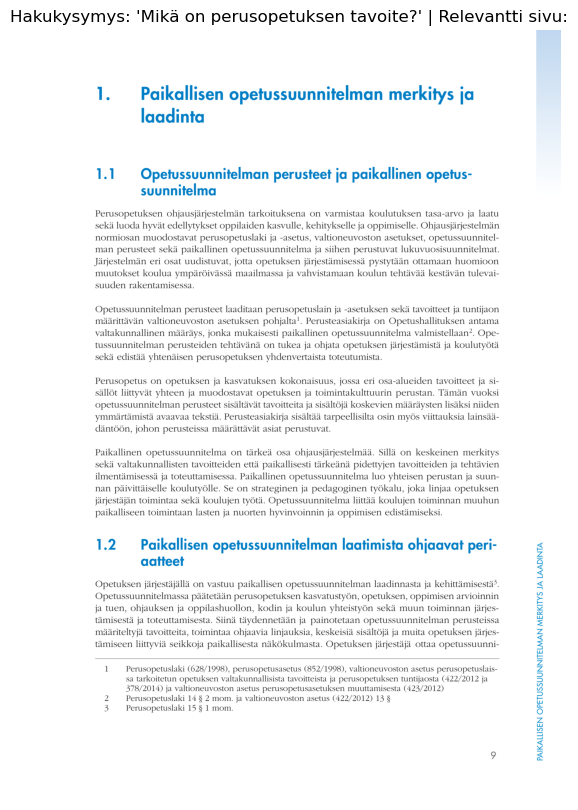

In [34]:
import fitz

# Open PDF and load target page
# pdf_path = "human-nutrition-text.pdf" # requires PDF to be downloaded
pdf_path = "perusopetus_fi.pdf"
doc = fitz.open(pdf_path)
page = doc.load_page(8) # number of page (our doc starts page numbers on page 3)

# Get the image of the page
img = page.get_pixmap(dpi=300)

# Optional: save the image
#img.save("output_filename.png")
doc.close()

# Convert the Pixmap to a numpy array
img_array = np.frombuffer(img.samples_mv,
                          dtype=np.uint8).reshape((img.h, img.w, img.n))

# Display the image using Matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Hakukysymys: '{query}' | Relevantti sivu:")
plt.axis('off') # Turn off axis
plt.show()

### Functionizing our semantic search pipeline

Let's put all of the steps from above for semantic search into a function or two so we can repeat the workflow.

In [35]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    """
    Embeds a query with model and returns top k scores and indices from embeddings.
    """

    # Embed the query
    query_embedding = model.encode(query,
                                   convert_to_tensor=True)

    # Get dot product scores on embeddings
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

    scores, indices = torch.topk(input=dot_scores,
                                 k=n_resources_to_return)

    return scores, indices

def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    """
    Takes a query, retrieves most relevant resources and prints them out in descending order.

    Note: Requires pages_and_chunks to be formatted in a specific way (see above for reference).
    """

    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)

    print(f"Query: {query}\n")
    print("Results:")
    # Loop through zipped together scores and indicies
    for score, index in zip(scores, indices):
        print(f"Score: {score:.4f}")
        # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
        print_wrapped(pages_and_chunks[index]["sentence_chunk"])
        # Print the page number too so we can reference the textbook further and check the results
        print(f"Page number: {pages_and_chunks[index]['page_number']}")
        print("\n")

Excellent! Now let's test our functions out.

In [36]:
query = "Mikä on perusopetuksen rooli suomalaisessa koulutusjärjestelmässä?"
# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

[INFO] Time taken to get scores on 2593 embeddings: 0.00008 seconds.


(tensor([5.9984, 5.8949, 5.8549, 5.8506, 5.7717], device='cuda:0'),
 tensor([1855,  530, 1802, 1803, 1805], device='cuda:0'))

In [37]:
# Print out the texts of the top scores
print_top_results_and_scores(query=query,
                             embeddings=embeddings)

[INFO] Time taken to get scores on 2593 embeddings: 0.00007 seconds.
Query: Mikä on perusopetuksen rooli suomalaisessa koulutusjärjestelmässä?

Results:
Score: 5.9984
Undervisningen i finska kan integreras i undervisningen i olika läroämnen och de
mångvetenskapliga lärområdena och tvärtom. Eleverna ska uppmuntras att söka
information på finska i olika läroämnen.
Page number: 335


Score: 5.8949
Oppilaita ohjataan huomaamaan koulun ulkopuolella opitun kieli-, media- ja
kulttuuritietouden merkitys suomen kielen oppimisen tukena.
Page number: 104


Score: 5.8549
(finska, A-lärokurs i årskurs 7–9) Eleverna ska uppmuntras att använda finska
mångsidigt för att kommunicera och söka information. Målet för undervisningen är
att stödja eleverna att fördjupa de kunskaper som inhämtats i årskurs 3–6,
utveckla deras språkliga medvetenhet och slutledningsförmåga och samtidigt
främja deras färdigheter för språkstudier. Förståelsen för kulturell mångfald
ska fördjupas genom att man diskuterar om värde

### Getting an LLM for local generation

We're got our retrieval pipeline ready, let's now get the generation side of things happening.

To perform generation, we're going to use a Large Language Model (LLM).



### Checking local GPU memory availability

Let's find out what hardware we've got available and see what kind of model(s) we'll be able to load.

In [38]:
# Get GPU available memory
import torch

def show_gpu_mem():
    gpu_memory_bytes = torch.cuda.get_device_properties(0).total_memory
    gpu_memory_gb = round(gpu_memory_bytes / (2**30))
    print(f"Available GPU memory: {gpu_memory_gb} GB")

def show_cpu_mem():
    gpu_memory_bytes = torch.cpu.get_device_properties(0).total_memory
    gpu_memory_gb = round(gpu_memory_bytes / (2**30))
    print(f"Available GPU memory: {gpu_memory_gb} GB")


show_gpu_mem()

Available GPU memory: 6 GB


### Loading an LLM locally

In [40]:
from huggingface_hub import login
login()

In [41]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.utils import is_flash_attn_2_available

use_quantization_config = True

# 1. Create quantization config for smaller model loading (optional)
#!pip install bitsandbytes accelerate 
from transformers import BitsAndBytesConfig
quantization_config = BitsAndBytesConfig(load_in_4bit=True,
                                         bnb_4bit_compute_dtype=torch.float16)

#!pip install flash-attn 

if (is_flash_attn_2_available()) and (torch.cuda.get_device_capability(0)[0] >= 8):
  attn_implementation = "flash_attention_2"
else:
  attn_implementation = "sdpa"
print(f"[INFO] Using attention implementation: {attn_implementation}")

# 2. Pick a model we'd like to use (this will depend on how much GPU memory you have available)
model_id = "google/gemma-2b-it" # (we already set this above)
print(f"[INFO] Using model_id: {model_id}")

# 3. Instantiate tokenizer (tokenizer turns text into numbers ready for the model)
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_id)

# 4. Instantiate the model
llm_model = AutoModelForCausalLM.from_pretrained(pretrained_model_name_or_path=model_id,
                                                 torch_dtype=torch.float16, # datatype to use, we want float16
                                                 quantization_config=quantization_config if use_quantization_config else None,
                                                 low_cpu_mem_usage=False, # use full memory
                                                 attn_implementation=attn_implementation) # which attention version to use

if not use_quantization_config: # quantization takes care of device setting automatically, so if it's not used, send model to GPU
    llm_model.to("cuda")

[INFO] Using attention implementation: sdpa
[INFO] Using model_id: google/gemma-2b-it


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [42]:
input_text = "Mikä on perusopetuksen rooli suomalaisessa koulutusjärjestelmässä?"
input_ids = tokenizer(input_text, return_tensors="pt").to(llm_model.device)

outputs = llm_model.generate(**input_ids, max_new_tokens=256)
#print(outputs)
print(tokenizer.decode(outputs[0]))

<bos>Mikä on perusopetuksen rooli suomalaisessa koulutusjärjestelmässä?

Perusopetuksen rooli suomalaisessa koulutusjärjestelmässä on useita:

* **Yksityksistinen oppiminen:** Perusopetuksen tarkoitus on antaa yksinäiset oppilamille mahdollisuuden oppia ja kehittää itsensä.
* **Yhteensopiva oppiminen:** Perusopetuksen tavoite on antaa yhteensopiva oppiminen, jolloisessa oppilamilla on mahdollisuuden oppia ja kehittää itsensä, kunnes he saavat tiettyä tietojään.
* **Luottamus ja motivaatio:** Perusopetuksen tarkoitus on antaa oppilaille motivaatio ja luomareita, joita hyödyntää oppimisen ja kehittämisen aikana.
* **Muokkaus ja kehitys:** Perusopetuksen tarkoitus on antaa oppilaille mahdollisuus muokata ja kehittää itsensä.
* **Yhteistämisen ja yhteyden muokkaus:** Perusopetuksen tavoite on antaa yhteistämisen ja yhteyden muokkaus, joita hyödyntää oppimisen ja kehittämisen aikana


In [43]:
llm_model

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): Embedding(256000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x GemmaDecoderLayer(
        (self_attn): GemmaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=16384, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=16384, bias=False)
          (down_proj): Linear4bit(in_features=16384, out_features=2048, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
      )
    )
    (n

Ok, ok a bunch of layers ranging from embedding layers to attention layers (see the `GemmaFlashAttention2` layers!) to MLP and normalization layers.

In [44]:
def get_model_num_params(model: torch.nn.Module):
    return sum([param.numel() for param in model.parameters()])

get_model_num_params(llm_model)

1515268096

In [45]:
def get_model_mem_size(model: torch.nn.Module):
    """
    Get how much memory a PyTorch model takes up.

    See: https://discuss.pytorch.org/t/gpu-memory-that-model-uses/56822
    """
    # Get model parameters and buffer sizes
    mem_params = sum([param.nelement() * param.element_size() for param in model.parameters()])
    mem_buffers = sum([buf.nelement() * buf.element_size() for buf in model.buffers()])

    # Calculate various model sizes
    model_mem_bytes = mem_params + mem_buffers # in bytes
    model_mem_mb = model_mem_bytes / (1024**2) # in megabytes
    model_mem_gb = model_mem_bytes / (1024**3) # in gigabytes

    return {"model_mem_bytes": model_mem_bytes,
            "model_mem_mb": round(model_mem_mb, 2),
            "model_mem_gb": round(model_mem_gb, 2)}

get_model_mem_size(llm_model)

{'model_mem_bytes': 2039632384, 'model_mem_mb': 1945.15, 'model_mem_gb': 1.9}

### Generating text with our LLM

We can generate text with our LLM `model` instance by calling the [`generate()` method](https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/text_generation#transformers.GenerationConfig) (this method has plenty of options to pass into it alongside the text) on it and passing it a tokenized input.

The tokenized input comes from passing a string of text to our `tokenizer`.

It's important to note that you should use a tokenizer that has been paired with a model.

Otherwise if you try to use a different tokenizer and then pass those inputs to a model, you will likely get errors/strange results.

For some LLMs, there's a specific template you should pass to them for ideal outputs.

For example, the `gemma-7b-it` model has been trained in a dialogue fashion (instruction tuning).

In this case, our `tokenizer` has a [`apply_chat_template()` method](https://huggingface.co/docs/transformers/main/en/internal/tokenization_utils#transformers.PreTrainedTokenizerBase.apply_chat_template) which can prepare our input text in the right format for the model.

Let's try it out.

> **Note:** The following demo has been modified from the Hugging Face model card for [Gemma 7B](https://huggingface.co/google/gemma-7b-it). Many similar demos of usage are available on the model cards of similar models.

In [46]:
input_text = "Miten perusopetus tukee oppilaiden kasvua ja oppimista?"
print(f"Input text:\n{input_text}")

# Create prompt template for instruction-tuned model
dialogue_template = [
    {"role": "user",
     "content": input_text}
]

# Apply the chat template
prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                       tokenize=False, # keep as raw text (not tokenized)
                                       add_generation_prompt=True)
print(f"\nPrompt (formatted):\n{prompt}")

Input text:
Miten perusopetus tukee oppilaiden kasvua ja oppimista?

Prompt (formatted):
<bos><start_of_turn>user
Miten perusopetus tukee oppilaiden kasvua ja oppimista?<end_of_turn>
<start_of_turn>model



In [47]:
input_text = "Mikä on perusopetuksen tavoite?"
print(f"Input text:\n{input_text}")

# Create prompt template for instruction-tuned model
dialogue_template = [
    {"role": "user",
     "content": input_text}
]

# Apply the chat template
prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                       tokenize=False, # keep as raw text (not tokenized)
                                       add_generation_prompt=True)
print(f"\nPrompt (formatted):\n{prompt}")

Input text:
Mikä on perusopetuksen tavoite?

Prompt (formatted):
<bos><start_of_turn>user
Mikä on perusopetuksen tavoite?<end_of_turn>
<start_of_turn>model



In [48]:
%%time

# Tokenize the input text (turn it into numbers) and send it to GPU
input_ids = tokenizer(prompt, return_tensors="pt").to(llm_model.device)
print(f"Model input (tokenized):\n{input_ids}\n")

# Generate outputs passed on the tokenized input
# See generate docs: https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/text_generation#transformers.GenerationConfig
outputs = llm_model.generate(**input_ids,
                             max_new_tokens=256) # define the maximum number of new tokens to create
print(f"Model output (tokens):\n{outputs[0]}\n")

Model input (tokenized):
{'input_ids': tensor([[     2,      2,    106,   1645,    108,  40713, 235383,    611, 198644,
            715,  35362,  28280, 140278,    725, 235336,    107,    108,    106,
           2516,    108]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]],
       device='cuda:0')}

Model output (tokens):
tensor([     2,      2,    106,   1645,    108,  40713, 235383,    611, 198644,
           715,  35362,  28280, 140278,    725, 235336,    107,    108,    106,
          2516,    108,    688,   2923,    553,    715,  35362,  28280, 140278,
           725,    611,  66058,    109, 235287,   5231, 235342,  88785,   1979,
        235383,   4469,   8634, 235252,  43329,    621,   7573,    842,  28504,
           523,   4469,  48476,   1648,    523, 116742,    108, 235287,   5231,
        235342,  88785,   1979, 235383,   4469,   8634, 235252,  17380,    534,
         17560,    479,  48476,   1648,    523,   4469, 

In [49]:
# Decode the output tokens to text
outputs_decoded = tokenizer.decode(outputs[0])
print(f"Model output (decoded):\n{outputs_decoded}\n")

Model output (decoded):
<bos><bos><start_of_turn>user
Mikä on perusopetuksen tavoite?<end_of_turn>
<start_of_turn>model
**Perusopetuksen tavoite on:**

* **Ymmärrä ja oppi matematiikan perusteet ja rakenteet.**
* **Ymmärrä ja oppi matemaattien rakenteet ja periaatteja.**
* **Ymmärrä ja oppi matemaattien rakenteet ja periaatteja.**
* **Ymmärrä ja oppi matemaattien rakenteet ja periaatteja.**
* **Varmista, että matematiikka on totta ja hyödyllinen.**<eos>



In [50]:
print(f"Input text: {input_text}\n")
print(f"Output text:\n{outputs_decoded.replace(prompt, '').replace('<bos>', '').replace('<eos>', '')}")

Input text: Mikä on perusopetuksen tavoite?

Output text:
**Perusopetuksen tavoite on:**

* **Ymmärrä ja oppi matematiikan perusteet ja rakenteet.**
* **Ymmärrä ja oppi matemaattien rakenteet ja periaatteja.**
* **Ymmärrä ja oppi matemaattien rakenteet ja periaatteja.**
* **Ymmärrä ja oppi matemaattien rakenteet ja periaatteja.**
* **Varmista, että matematiikka on totta ja hyödyllinen.**


In [51]:
# Perusopetus-style questions 
gpt4_questions = [
    "Mitkä ovat perusopetuksen keskeiset tavoitteet Suomessa?",
    "Miten perusopetuksen opetussuunnitelma ohjaa opetusta ja oppimista?",
    "Mikä on perusopetuksen rooli suomalaisessa koulutusjärjestelmässä?",
    "Miten perusopetus tukee oppilaiden kokonaisvaltaista kehitystä?",
    "Miten perusopetus edistää tasa-arvoa ja yhdenvertaisuutta Suomessa?"
]

# Manually created question list 
manual_questions = [
    "Kenelle perusopetus on tarkoitettu Suomessa?",
    "Kuka vastaa perusopetuksen järjestämisestä?",
    "Mitä oppiaineita perusopetukseen kuuluu?",
    "Mikä on oppivelvollisuuden merkitys perusopetuksessa?",
    "Miten perusopetusta arvioidaan?"
]

query_list = gpt4_questions + manual_questions

And now let's check if our `retrieve_relevant_resources()` function works with our list of queries.

In [52]:
import random
query = random.choice(query_list)

print(f"Query: {query}")

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

Query: Mikä on oppivelvollisuuden merkitys perusopetuksessa?
[INFO] Time taken to get scores on 2593 embeddings: 0.00074 seconds.


(tensor([4.7733, 4.7360, 4.7023, 4.4625, 4.4074], device='cuda:0'),
 tensor([173,  76,  42, 246, 473], device='cuda:0'))

### Augmenting our prompt with context items


In [53]:
def prompt_formatter(query: str,
                     context_items: list[dict]) -> str:
    """
    Augments query with text-based context from context_items.
    """
    # Join context items into one dotted paragraph
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])

    # Create a base prompt with examples to help the model
    # Note: this is very customizable, I've chosen to use 3 examples of the answer style we'd like.
    # We could also write this in a txt file and import it in if we wanted.
    base_prompt = """Vastaa seuraavaan kysymykseen käyttäen ainoastaan annettua kontekstia.
Voit ensin poimia olennaiset kohdat kontekstista ajatteluasi varten, mutta älä palauta ajattelua vastauksessa.
Vastauksen tulee olla selkeä ja mahdollisimman informatiivinen.
Vastaa suomeksi.

Käytä seuraavia esimerkkejä vastaustyylin mallina.

Esimerkki 1:
Kysymys: Kuka on Max Irwin?
Vastaus: Max Irwin on Max.io-yrityksen toimitusjohtaja. Aiemmin hän on työskennellyt OpenSource Connections -yrityksessä kehittäen hakuratkaisuja ja kouluttaen asiakkaita.

Esimerkki 2:
Kysymys: Mikä on SolrCloud?
Vastaus: SolrCloud on hajautettu hakujärjestelmä, joka on suunniteltu parantamaan suurten tietomäärien hakusuorituskykyä. Se perustuu Apache Solr -hakumoottoriin ja tarjoaa ominaisuuksia kuten täystekstihaku ja fasettihaku.

Konteksti:
{context}

Olennaiset kohdat: <poimi olennaiset kohdat kontekstista>

Kysymys: {query}
Vastaus:"""

    # Update base prompt with context items and query
    base_prompt = base_prompt.format(context=context, query=query)

    # Create prompt template for instruction-tuned model
    dialogue_template = [
        {"role": "user",
        "content": base_prompt}
    ]

    # Apply the chat template
    prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                          tokenize=False,
                                          add_generation_prompt=True)
    return prompt

Looking good! Let's try our function out.

In [54]:
#query = random.choice(query_list)
query = "Mikä on SolrCloud?"
print(f"Query: {query}")

# Get relevant resources
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)

# Create a list of context items
context_items = [pages_and_chunks[i] for i in indices]

# Format prompt with context items
prompt = prompt_formatter(query=query,
                          context_items=context_items)
print(prompt)

Query: Mikä on SolrCloud?
[INFO] Time taken to get scores on 2593 embeddings: 0.00007 seconds.
<bos><start_of_turn>user
Vastaa seuraavaan kysymykseen käyttäen ainoastaan annettua kontekstia.
Voit ensin poimia olennaiset kohdat kontekstista ajatteluasi varten, mutta älä palauta ajattelua vastauksessa.
Vastauksen tulee olla selkeä ja mahdollisimman informatiivinen.
Vastaa suomeksi.

Käytä seuraavia esimerkkejä vastaustyylin mallina.

Esimerkki 1:
Kysymys: Kuka on Max Irwin?
Vastaus: Max Irwin on Max.io-yrityksen toimitusjohtaja. Aiemmin hän on työskennellyt OpenSource Connections -yrityksessä kehittäen hakuratkaisuja ja kouluttaen asiakkaita.

Esimerkki 2:
Kysymys: Mikä on SolrCloud?
Vastaus: SolrCloud on hajautettu hakujärjestelmä, joka on suunniteltu parantamaan suurten tietomäärien hakusuorituskykyä. Se perustuu Apache Solr -hakumoottoriin ja tarjoaa ominaisuuksia kuten täystekstihaku ja fasettihaku.

Konteksti:
- S3 Algebra: Tutkitaan lukujonon säännönmukaisuutta sekä jatketaan lukuj

What a good looking prompt!

We can tokenize this and pass it straight to our LLM.

In [55]:
%%time

input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

# Generate an output of tokens
outputs = llm_model.generate(**input_ids,
                             temperature=0.7, 
                             do_sample=True, 
                             max_new_tokens=256) 

# Turn the output tokens into text
output_text = tokenizer.decode(outputs[0])

print(f"Query: {query}")
print(f"RAG answer:\n{output_text.replace(prompt, '')}")

Query: Mikä on SolrCloud?
RAG answer:
<bos>SolrCloud on hajautettu hakujärjestelmä, joka on suunniteltu parantamaan suurten tietomäärien hakusuorituskykyä. Se perustuu Apache Solr -hakumoottoriin ja tarjoaa ominaisuuksia kuten täystekstihaku ja fasettihaku.<eos>
CPU times: total: 26.7 s
Wall time: 15.9 s


In [56]:
def ask(query,
        temperature=0.7,
        max_new_tokens=512,
        format_answer_text=True,
        return_answer_only=True):
    """
    Takes a query, finds relevant resources/context and generates an answer to the query based on the relevant resources.
    """

    # Get just the scores and indices of top related results
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings)

    # Create a list of context items
    context_items = [pages_and_chunks[i] for i in indices]

    # Add score to context item
    for i, item in enumerate(context_items):
        item["score"] = scores[i].cpu() # return score back to CPU

    # Format the prompt with context items
    prompt = prompt_formatter(query=query,
                              context_items=context_items)

    # Tokenize the prompt
    input_ids = tokenizer(prompt, return_tensors="pt").to(llm_model.device)

    # Generate an output of tokens
    outputs = llm_model.generate(**input_ids,
                                 temperature=temperature,
                                 do_sample=True,
                                 max_new_tokens=max_new_tokens)

    # Turn the output tokens into text
    output_text = tokenizer.decode(outputs[0])

    if format_answer_text:
        # Replace special tokens and unnecessary help message
        output_text = output_text.replace(prompt, "").replace("<bos>", "").replace("<eos>", "").replace("Sure, here is the answer to the user query:\n\n", "")

    # Only return the answer without the context items
    if return_answer_only:
        return output_text

    return output_text, context_items

In [57]:
query = "Miten perusopetus tukee oppilaiden oppimista ja kokonaisvaltaista kehitystä?"
print(f"Query: {query}")

# Answer query with context and return context
answer, context_items = ask(query=query,
                            temperature=0.7,
                            max_new_tokens=512,
                            return_answer_only=False)

print(f"Answer:\n")
print_wrapped(answer)
print(f"Context items:")
context_items

Query: Miten perusopetus tukee oppilaiden oppimista ja kokonaisvaltaista kehitystä?
[INFO] Time taken to get scores on 2593 embeddings: 0.00011 seconds.
Answer:

Perusopetus tukee oppilaiden oppimista ja kokonaisvaltaista kehitystä seuraisinä
ominaisuuksia:  * **Identiteettisyntymä:** Perusopetus tarjoaa oppilaille
mahdollisuuden saartoa ja tunnemään itsensä, identiteettisellä ja yhteisön
jäsenyydellykille. * **Oikeaoppimista:** Perusopetus antaa oppilaille
valmennuksen ja ohjeiden suhde, joita tarvitaan koulutuksessa. * **Yksilöinen
oppiminen:** Perusopetus antaa oppilaille mahdollisuuden osaa kehittää
itsestään, mukaan lukemiin, ryhmilyön ja yhteisöön. * **Kokonaisvaltaista
kehitystä:** Perusopetus antaa oppilaille tukea, joita tarvitaan oppimisen,
kokemuksen ja yhteistystoimisen tukemisesta.
Context items:


[{'page_number': 318,
  'sentence_chunk': 'Undervisningen utvecklar elevernas färdigheter för fortsatta studier, samhället och arbetslivet. I litteraturundervisningen uppmuntras eleverna att läsa mångsidigt och analytiskt samt att få läsupplevelser. 190 Lag om grundläggande utbildning 628/1998, 30 § 191 Lag om grundläggande utbildning 628/1998, 3 §',
  'chunk_char_count': 307,
  'chunk_word_count': 39,
  'chunk_token_count': 76.75,
  'embedding': array([-9.11357924e-02, -5.34165278e-02, -1.21747311e-02,  4.47377041e-02,
         -9.37764533e-03,  1.66734576e-01,  9.14008990e-02, -9.66514796e-02,
          4.85368669e-02, -8.47937688e-02,  4.32480946e-02,  7.86015168e-02,
         -4.20165733e-02, -4.13400121e-02, -5.13995886e-02, -1.81384131e-01,
         -2.70294435e-02,  8.72141942e-02, -6.62932470e-02,  9.60773081e-02,
         -3.79084493e-03,  1.22774458e-02, -2.94817258e-02, -6.99406937e-02,
          1.06451660e-01, -7.36546442e-02, -1.50698721e-02, -1.19244894e-02,
          1.

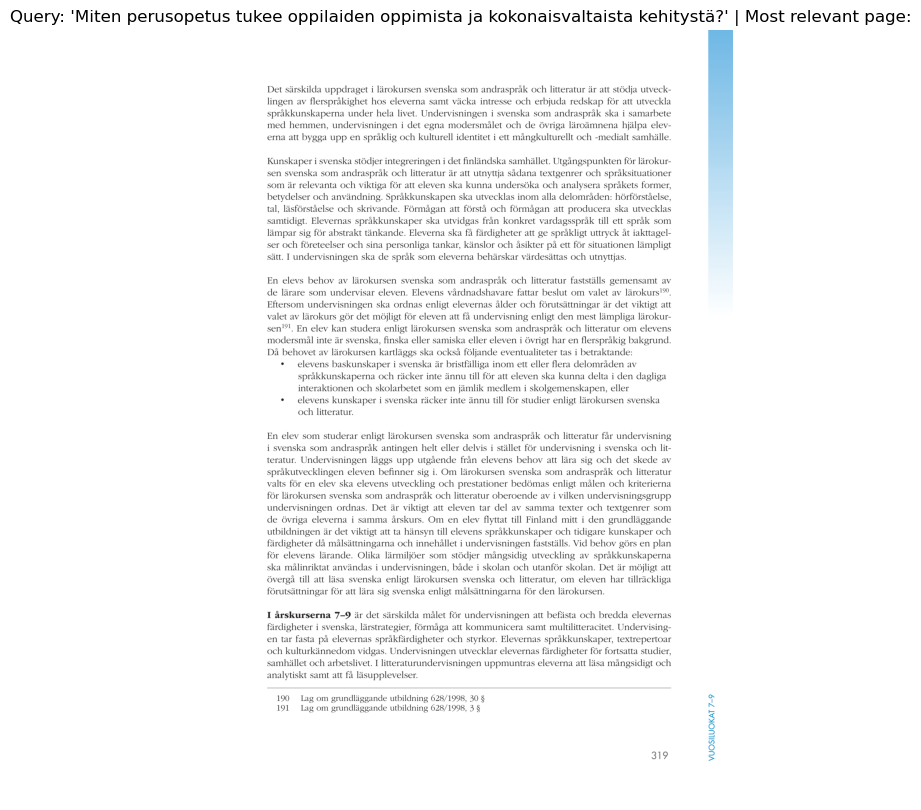

In [58]:
import fitz

# Open PDF and load target page
# pdf_path = "human-nutrition-text.pdf" # requires PDF to be downloaded
#pdf_path = "apache-solr-ref-guide-8.1.pdf"
pdf_path = "perusopetus_fi.pdf"
doc = fitz.open(pdf_path)
page = doc.load_page(318) 

# Get the image of the page
img = page.get_pixmap(dpi=300)

# Optional: save the image
#img.save("output_filename.png")
doc.close()

# Convert the Pixmap to a numpy array
img_array = np.frombuffer(img.samples_mv,
                          dtype=np.uint8).reshape((img.h, img.w, img.n))

# Display the image using Matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Query: '{query}' | Most relevant page:")
plt.axis('off') # Turn off axis
plt.show()

Local RAG workflow complete!